In [1]:
import numpy as np
import scanpy as sc
import scvelo as scv
import anndata as ad
import pandas as pd
import scipy
import os
import torch
from matplotlib import pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from umap import UMAP
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import sys; sys.path += ['./../../']
from CardamomOT import NetworkModel as CardamomNetworkModel
from CardamomOT.inference.simulations import kon_ref, simulate_next_prot_ode
from harissa import NetworkModel as HarissaNetworkModel
sys.path.append("./_scripts/") 
import rf

In [2]:
cmap = plt.get_cmap('tab20')
colors_methods = {'CardamomOT': (cmap(6), cmap(7)), 'CARDAMOM1': (cmap(8), cmap(9)),'REFERENCE_FITTING': (cmap(18), cmap(19)),
    'GENIE3': (cmap(0), cmap(1)), 'SINCERITIES': (cmap(2), cmap(3)),
    'PIDC': (cmap(4), cmap(5)), 'PEARSON': (cmap(14), cmap(15)),
    'SCRIBE_timed': (cmap(10), cmap(11)), 'SCRIBE_wadd': (cmap(12), cmap(13)),
    'SCRIBE_pseudotimed': (cmap(16), cmap(17)), 'Random': 2*('lightgray',)}

In [3]:
def step_ode_modif(d1, ks, inter, basal, scale, P):
    """Euler step for the deterministic limit model."""
    a = kon_ref(P, ks, inter, basal)
    delta_P = d1 * (scale * a - P)
    return P + delta_P, delta_P

def kon_harissa(basal, inter, k0, k1, P):
    """Compute the kon rates according to the Harissa model."""
    phi = 1 / (1 + np.exp(-(basal + P @ inter)))
    kon = k0 + (k1 - k0) * phi
    kon[0] = 0
    return kon

def compute_similarity_matrix(deltas):
    """Weighted cosine similarity matrix for a list of delta arrays."""
    n = len(deltas)
    matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            norms = np.linalg.norm(deltas[i], axis=1) * np.linalg.norm(deltas[j], axis=1)
            weights = norms / norms.sum()
            matrix[i, j] = np.sum(cosine_similarity(deltas[i], deltas[j]).diagonal() * weights)
    return matrix

def fit_transform_umap(base, *endpoints, **umap_kwargs):
    """Fit a UMAP on the union of base + endpoints, return (base_2d, [delta_2d, ...])."""
    umap = UMAP(**umap_kwargs)
    umap.fit(np.vstack([base, *endpoints]))
    base_2d = umap.transform(base)
    deltas_2d = [umap.transform(ep) - base_2d for ep in endpoints]
    return base_2d, deltas_2d

def run_fig_5(run_name):
    # ---- Harissa deltas ----
    k0_h = model_harissa.a[0] * model_harissa.d[0]
    k1_h = model_harissa.a[1] * model_harissa.d[0]
    delta_rna_harissa  = np.zeros_like(rna_traj, dtype=float)
    delta_prot_harissa = np.zeros_like(prot_traj_scaled, dtype=float)
    for n, cell in enumerate(prot_traj_scaled):
        kon = kon_harissa(model_harissa.basal, model_harissa.inter, k0_h, k1_h, cell)
        delta_rna_harissa[n]  = kon / model_harissa.a[-1] - model_harissa.d[0] * rna_traj[n]
        delta_prot_harissa[n] = model_harissa.d[1] * (kon / k1_h - cell)

    # ---- CardamomOT fit ----
    time = data[1:, 0]
    x = data[1:, 1:].copy()
    x[:, 0] = time
    G = x.shape[1]
    model = CardamomNetworkModel(G - 1)
    model.d = np.loadtxt('BN8/Data/Rates/degradation_rates.txt', dtype=float, delimiter='\t').T[:, :rna_traj.shape[1]]
    print(x.shape)
    model.fit_mixture(x, min_components=2, max_components=2, max_iter_kinetics=0)
    model.fit_network(x, intensity_prior=100)
    model.adapt_to_unitary()

    # ---- Carda deltas ----
    c       = model.a[-1]
    ks_cells = np.max(model.a[:-1], axis=0)
    ks      = (model.a[:-1] / ks_cells).T
    delta_rna_carda  = model.d[0] * (model.kon_theta * ks_cells / c - rna_traj)
    delta_prot_carda = np.zeros_like(prot_traj_scaled, dtype=float)
    for cell in range(prot_traj_scaled.shape[0]):
        _, delta_P = step_ode_modif(model.d[1], ks, model.inter, model.basal, 1,
                                    prot_traj_scaled[cell].reshape(1, -1))
        delta_prot_carda[cell] = delta_P[0]

    # ---- Reference Fitting ----
    adata_rf = ad.AnnData(X=rna_traj, obs={'time': time})
    options = dict(lr=0.05, reg_sinkhorn=0.1, reg_A=1, reg_A_elastic=0.5, iter=1000,
                   ot_coupling=True, optimizer=torch.optim.Adam, n_pca_components=-1)
    estim = rf.Estimator([adata_rf], kos=[None], lr=options['lr'],
                         reg_sinkhorn=options['reg_sinkhorn'], reg_A=options['reg_A'],
                         reg_A_elastic=options['reg_A_elastic'], iter=options['iter'],
                         ot_coupling=options['ot_coupling'], optimizer=options['optimizer'],
                         norm=False, t_key='time')
    estim.fit(print_iter=10, alg='alternating', update_couplings_iter=250)

    P_rf   = np.array(torch.linalg.matrix_exp(1 / estim.T * estim.A.cpu()))
    b_rf   = estim.b.cpu().numpy()
    scaler = [1, 1]

    # Strip stimulus column
    delta_rna_rf    = (rna_traj    @ P_rf + b_rf - rna_traj)[:, 1:]    * scaler[0]
    delta_prot_rf   = (prot_traj_scaled @ P_rf + b_rf - prot_traj_scaled)[:, 1:] * scaler[1]
    delta_rna_carda_s  = delta_rna_carda[:, 1:]
    delta_prot_carda_s = delta_prot_carda[:, 1:]
    delta_rna_h_s   = delta_rna_harissa[:, 1:]
    delta_prot_h_s  = delta_prot_harissa[:, 1:]

    # Reffit per-cell OT coupling correction
    unique_times = np.unique(time)
    for number, cell in enumerate(prot_traj_scaled):
        if number // 100 < len(unique_times) - 1:
            P2 = (np.dot(estim.Ts[0][number // 100][number % 100].cpu().numpy(),
                         prot_traj_scaled[100 * (number // 100):100 * (number // 100 + 1)]) * 100)[1:]
            delta_prot_rf[number] = (P2 - cell[1:]) * scaler[1]

    rna_s  = rna_traj[:, 1:]
    prot_s = prot_traj_scaled[:, 1:]

    # ---- Subsample ----
    n_sub = 100
    np.random.seed(42)
    sub_idx = np.concatenate([
        np.random.choice(np.where(time == t)[0], size=min(n_sub, (time == t).sum()), replace=False)
        for t in unique_times[1:]
    ])
    time_sub         = time[sub_idx]
    rna_sub          = rna_s[sub_idx]
    prot_sub         = prot_s[sub_idx]
    d_rna_carda_sub  = delta_rna_carda_s[sub_idx]
    d_prot_carda_sub = delta_prot_carda_s[sub_idx]
    d_rna_h_sub      = delta_rna_h_s[sub_idx]
    d_prot_h_sub     = delta_prot_h_s[sub_idx]
    d_rna_rf_sub     = delta_rna_rf[sub_idx]
    d_prot_rf_sub    = delta_prot_rf[sub_idx]

    # ---- UMAP embeddings ----
    umap_kw = dict(n_components=2, random_state=42, min_dist=0.7)
    rna_2d, (d_rna_rf_2d, d_rna_carda_2d, d_rna_h_2d) = fit_transform_umap(
        rna_sub,
        rna_sub + d_rna_rf_sub * 0.5,
        rna_sub + d_rna_carda_sub,
        rna_sub + d_rna_h_sub,
        **umap_kw)
    prot_2d, (d_prot_rf_2d, d_prot_carda_2d, d_prot_h_2d) = fit_transform_umap(
        prot_sub,
        prot_sub + d_prot_rf_sub * 0.2,
        prot_sub + d_prot_carda_sub,
        prot_sub + d_prot_h_sub,
        **umap_kw)

    # ---- Figure 1: velocity quiver plots ----
    fig, axes = plt.subplots(3, 2, figsize=(14, 13))
    plot_cfg = [
        (axes[0, 0], rna_2d,  d_rna_h_2d,      'UMAP of RNA trajectories - Harissa'),
        (axes[0, 1], prot_2d, d_prot_h_2d,      'UMAP of Protein trajectories - Harissa'),
        (axes[1, 0], rna_2d,  d_rna_carda_2d,   'UMAP of RNA trajectories - CARDA'),
        (axes[1, 1], prot_2d, d_prot_carda_2d,  'UMAP of Protein trajectories - CARDA'),
        (axes[2, 0], rna_2d,  d_rna_rf_2d,      'UMAP of RNA trajectories - ReferenceFitting'),
        (axes[2, 1], prot_2d, d_prot_rf_2d,     'UMAP of Protein trajectories - ReferenceFitting'),
    ]
    for ax, emb, vel, title in plot_cfg:
        sc = ax.scatter(emb[:, 0], emb[:, 1], c=time_sub, cmap='viridis', alpha=0.6, s=15)
        ax.quiver(emb[:, 0], emb[:, 1], vel[:, 0], vel[:, 1],
                  angles='xy', scale_units='xy', scale=1, width=0.002, color='tab:red', alpha=0.6)
        ax.set(xlabel='UMAP 1', ylabel='UMAP 2', title=title)
        plt.colorbar(sc, ax=ax, label='Time')
    plt.tight_layout()
    plt.savefig(f'figure_5_1_{run_name}.pdf', dpi=300)
    plt.show()

    # ---- Figure 2: cosine similarity heatmaps ----
    not_last = time != unique_times[-1]
    methods = ['RefFit', 'CARDA', 'Harissa']
    sim_rna  = compute_similarity_matrix([delta_rna_rf[not_last],    delta_rna_carda_s[not_last],  delta_rna_h_s[not_last]])
    sim_prot = compute_similarity_matrix([delta_prot_rf[not_last],   delta_prot_carda_s[not_last], delta_prot_h_s[not_last]])

    fig, axes_hm = plt.subplots(1, 2, figsize=(14, 5))
    for ax, matrix, title in [
        (axes_hm[0], sim_rna,  'Cosine Similarity of RNA Deltas'),
        (axes_hm[1], sim_prot, 'Cosine Similarity of Protein Deltas'),
    ]:
        sns.heatmap(matrix, annot=True, fmt='.4f', cmap='gray', vmin=0, vmax=1,
                    xticklabels=methods, yticklabels=methods,
                    cbar_kws={'label': 'Cosine Similarity'}, ax=ax)
        ax.set_title(title)
    plt.tight_layout()
    plt.savefig(f'figure_5_2_{run_name}.pdf', dpi=300)
    plt.show()

    UMAPs = {'rna': rna_2d,   'prot': prot_2d,
             'rna_reffit': d_rna_rf_2d,   'prot_reffit': d_prot_rf_2d,
             'rna_carda':  d_rna_carda_2d, 'prot_carda':  d_prot_carda_2d,
             'rna_harissa': d_rna_h_2d,   'prot_harissa': d_prot_h_2d}
    cells = {'rna': rna_sub,  'prot': prot_sub,
             'rna_reffit': d_rna_rf_sub,   'prot_reffit': d_prot_rf_sub,
             'rna_carda':  d_rna_carda_sub, 'prot_carda':  d_prot_carda_sub,
             'rna_harissa': d_rna_h_sub,   'prot_harissa': d_prot_h_sub}

    return sim_rna, sim_prot, UMAPs, cells

# BN8

In [4]:
np.random.seed(0)

# Number of cells
C = 1000

# Time points
t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96] 
N = int(C /len(t))
k = np.linspace(0, C, len(t) + 1, dtype='int')
print(f't = {t}')
time = np.zeros(C, dtype='int')
for i in range(len(t)): time[k[i]:k[i+1]] = t[i]

# Number of genes
G = 8

# Prepare data
data = np.zeros((C+1,G+2), dtype='int')
data[0][1:] = np.arange(G+1)
data[1:,0] = time # Time points
data[1:,1] = 100 * (time > 0) # Stimulus

# Initialize the model
model_harissa = HarissaNetworkModel(G)
model_harissa.d[0] = 0.25
model_harissa.d[1] = 0.05

model_harissa.basal[1:] = [-4, -4, -4, -4, -4, -4, -4, -4]
model_harissa.inter[0, 1] = 10
model_harissa.inter[1, 2] = 10
model_harissa.inter[1, 3] = 10
model_harissa.inter[3, 2] = -10
model_harissa.inter[2, 3] = -10
model_harissa.inter[2, 2] = 5
model_harissa.inter[3, 3] = 5
model_harissa.inter[2, 4] = 10
model_harissa.inter[3, 5] = 10
model_harissa.inter[2, 5] = -10
model_harissa.inter[3, 4] = -10
model_harissa.inter[4, 7] = -10
model_harissa.inter[5, 6] = -10
model_harissa.inter[4, 6] = 10
model_harissa.inter[5, 7] = 10
model_harissa.inter[7, 8] = 10
model_harissa.inter[6, 8] = -10

inter_true = 1 * (abs(model_harissa.inter) > 0)

prot_traj = np.ones((C, G+1), dtype='float32')
for k in range(C):
    sim = model_harissa.simulate(time[k], burnin=5)
    prot_traj[k,1:] = sim.p[-1]
    data[k+1,2:] = np.random.poisson(sim.m[-1])
rna_traj = data[1:,1:].copy()
prot_traj_scaled = prot_traj / np.max(prot_traj, axis=0)

t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96]


(1000, 9)
Calibrating gene 4
Calibrating gene 5
Calibrating gene 8
Calibrating gene 7
Calibrating gene 2
Calibrating gene 3
Calibrating gene 6
Calibrating gene 1
Gene 1-1 calibrated... [0.039 2.027] 0.01911753446535833
Gene 2-2 calibrated... [0.006 1.006] 0.012442201803882582
Gene 3-3 calibrated... [0.008 0.975] 0.013081646224547916
Gene 4-4 calibrated... [0.006 0.764] 0.011023949852052756
Gene 5-5 calibrated... [0.007 0.952] 0.014360309436976505
Gene 6-6 calibrated... [0.007 0.788] 0.013979254121655679
Gene 7-7 calibrated... [0.006 0.75 ] 0.012780016524745969
Gene 8-8 calibrated... [0.007 0.667] 0.013115834408433568
Mean proba =  0.970544255344347 1.0
[fit_network] Cell counts per sample/timepoint and genes:
 [[100 100 100 100 100 100 100 100 100 100]] 9
[fit_network] Number of simulated cells per sample: [100]
[fit_network] Number of total cells per sample: [100]
1 0 | Errors (before, after): 0.69328, 0.35298 | alpha mean: 0.0100
number of non reached cells 331
2 0 | Errors (before, 

2026-03-25 16:20:32,382 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 8.394331e-03 max scale = 1.306e+00
2026-03-25 16:20:32,382 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 2.858022e-03 max scale = 1.321e+00
2026-03-25 16:20:32,383 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 7.808443e-03 max scale = 1.321e+00
2026-03-25 16:20:32,383 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 1.294136e-02 max scale = 1.306e+00
2026-03-25 16:20:32,383 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 1.320640e-03 max scale = 1.321e+00
2026-03-25 16:20:32,383 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 1.096944e-02 max scale = 1.306e+00
2026-03-25 16:20:32,383 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 1.102126e-02 max scale = 1.321e+00
2026-03-25 16:20:32,383 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 1.138266e-02 max scale = 1.320e+00


[adapt_unitary]  Static network unitary [array([[ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,
         0.   ],
       [ 5.421,  3.638, -0.419, -0.092, -0.001, -0.001, -0.008, -0.001,
         0.   ],
       [ 0.001,  4.936,  3.902, -0.001, -0.   , -3.712, -0.001, -0.001,
        -0.472],
       [ 0.087,  6.478, -0.001,  5.435, -5.815,  0.   ,  0.001, -0.   ,
         0.001],
       [ 0.   ,  3.702,  2.328, -2.713,  4.021, -1.619, -0.008, -0.   ,
        -0.   ],
       [ 0.104,  0.001, -3.991,  7.008, -2.637,  3.966, -0.   ,  0.192,
        -0.009],
       [ 0.001, -0.001,  0.148,  0.   ,  5.55 , -0.001,  6.825, -0.001,
        -0.001],
       [ 0.069, -0.001, -0.002,  0.05 , -3.394,  4.576,  0.   ,  6.173,
        -0.   ],
       [ 0.   ,  0.   , -0.019,  0.   , -0.001,  4.24 , -0.001,  0.088,
         7.646]])] [array([ 0.   , -3.737, -3.015, -3.761, -4.331, -3.854, -5.049, -3.595,
       -4.629])]
Updating transport plans
iteration 0, loss = -20689.849890402966, L

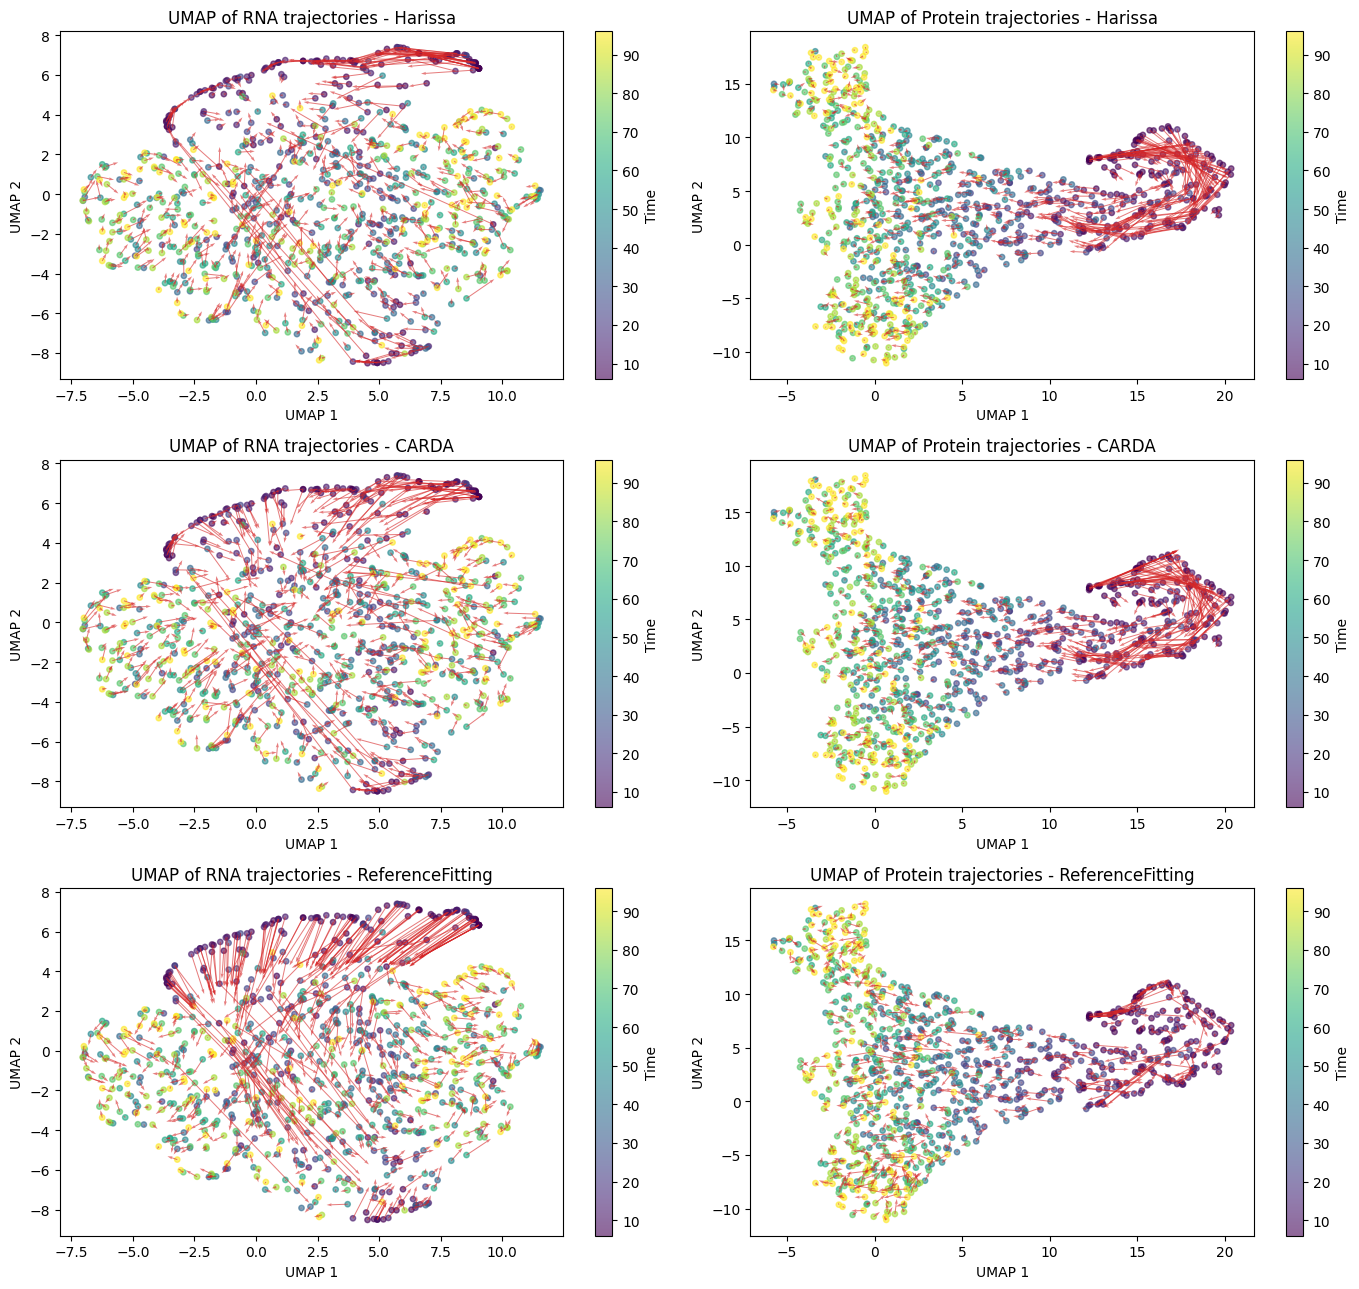

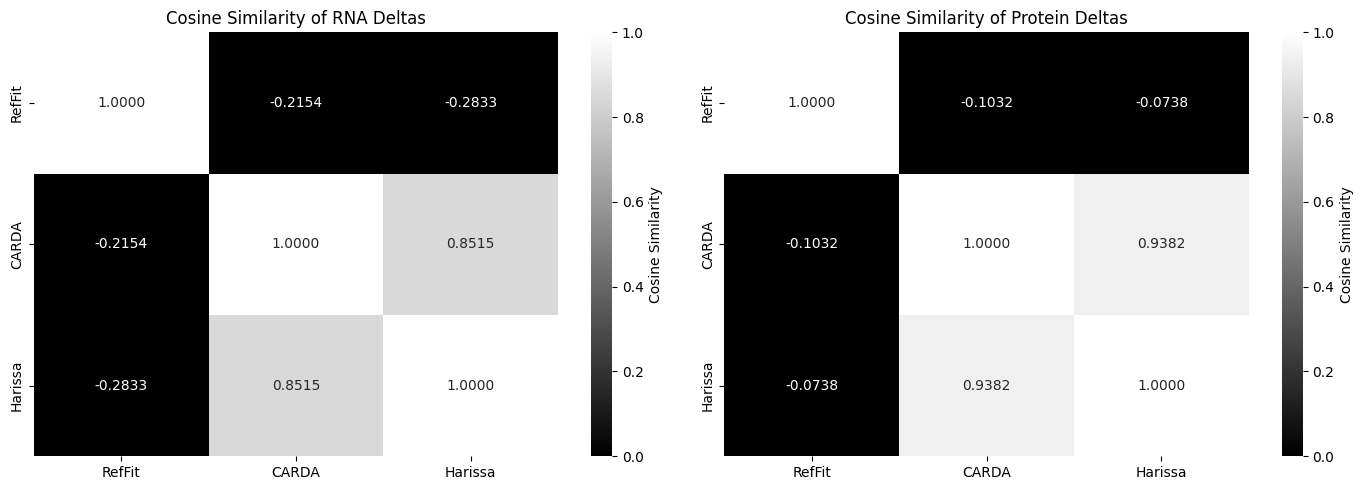

In [5]:
BN8_RNA, BN8_prot, BN8_UMAPs, BN8_cells = run_fig_5('BN8')

# FN8

In [6]:
np.random.seed(0)

# Number of cells
C = 1000
# Time points
t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96] # np.linspace(0, 25, 10, dtype='int')
N = int(C /len(t))
k = np.linspace(0, C, len(t) + 1, dtype='int')
print(f't = {t}')
time = np.zeros(C, dtype='int')
for i in range(len(t)): time[k[i]:k[i+1]] = t[i]

# Number of genes
G = 8

# Prepare data
data = np.zeros((C+1,G+2), dtype='int')
data[0][1:] = np.arange(G+1)
data[1:,0] = time # Time points
data[1:,1] = 100 * (time > 0) # Stimulus

# Initialize the model
model_harissa = HarissaNetworkModel(G)
model_harissa.d[0] = 0.4
model_harissa.d[1] = 0.08

model_harissa.basal[1:] = [-5, -5, -5, -5, -5, -5, -5, -5]
model_harissa.inter[0, 1] = 10
model_harissa.inter[1, 2] = 10
model_harissa.inter[2, 3] = 10
model_harissa.inter[3, 4] = 10
model_harissa.inter[3, 5] = 10
model_harissa.inter[3, 6] = 10
model_harissa.inter[4, 1] = -10
model_harissa.inter[5, 1] = -10
model_harissa.inter[6, 1] = -10
model_harissa.inter[4, 4] = 10
model_harissa.inter[5, 5] = 10
model_harissa.inter[6, 6] = 10
model_harissa.inter[4, 8] = -10
model_harissa.inter[4, 7] = -10
model_harissa.inter[6, 7] = 10
model_harissa.inter[7, 6] = 10
model_harissa.inter[8, 8] = 10

inter_true = 1 * (abs(model_harissa.inter) > 0)

prot_traj = np.ones((C, G+1), dtype='float32')
for k in range(C):
    sim = model_harissa.simulate(time[k], burnin=5)
    prot_traj[k,1:] = sim.p[-1]
    data[k+1,2:] = np.random.poisson(sim.m[-1])
rna_traj = data[1:,1:].copy()
prot_traj_scaled = prot_traj / np.max(prot_traj, axis=0)

t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96]


(1000, 9)
Calibrating gene 1
Calibrating gene 2
Calibrating gene 3
Calibrating gene 4
Calibrating gene 5
Calibrating gene 6
Calibrating gene 7
Calibrating gene 8
Gene 1-1 calibrated... [0.017 2.007] 0.019916405672662202
Gene 2-2 calibrated... [0.009 1.63 ] 0.01886891936160474
Gene 3-3 calibrated... [0.007 1.075] 0.014347874292772983
Gene 4-4 calibrated... [0.007 1.534] 0.014684189598562481
Gene 5-5 calibrated... [0.012 2.698] 0.024499787214457013
Gene 6-6 calibrated... [0.015 2.438] 0.024512190685865846
Gene 7-7 calibrated... [0.007 0.665] 0.01620572556094255
Gene 8-8 calibrated... [0.008 0.793] 0.07991833315446606
Mean proba =  0.9688328759567448 1.0
[fit_network] Cell counts per sample/timepoint and genes:
 [[100 100 100 100 100 100 100 100 100 100]] 9
[fit_network] Number of simulated cells per sample: [100]
[fit_network] Number of total cells per sample: [100]
1 0 | Errors (before, after): 0.69533, 0.27885 | alpha mean: 0.0100
number of non reached cells 336
2 0 | Errors (before, a

2026-03-25 16:21:27,871 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 1.823376e-03 max scale = 1.321e+00
2026-03-25 16:21:27,873 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 9.059650e-04 max scale = 1.321e+00
2026-03-25 16:21:27,878 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 6.768949e-03 max scale = 1.306e+00
2026-03-25 16:21:27,880 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 1.314215e-02 max scale = 1.321e+00
2026-03-25 16:21:27,882 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 1.019072e-02 max scale = 1.321e+00
2026-03-25 16:21:27,891 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 5.138332e-03 max scale = 1.321e+00
2026-03-25 16:21:28,312 | CardamomOT.inference.degradations | INFO | [Epoch 50/500] loss = 1.640141e-03 max scale = 1.683e+00
2026-03-25 16:21:28,402 | CardamomOT.inference.degradations | INFO | [Epoch 50/500] loss = 5.659870e-04 max scale = 1.667e+0

[adapt_unitary]  Static network unitary [array([[ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,
         0.   ],
       [ 5.803,  1.766,  0.001, -0.763, -6.43 ,  0.022, -4.223, -0.   ,
         0.   ],
       [ 0.   , 11.235,  3.224, -0.   , -0.   ,  0.   , -2.336, -0.   ,
        -0.   ],
       [-0.   ,  3.707,  7.851,  3.296,  0.001,  0.001,  0.   , -0.   ,
        -0.   ],
       [ 0.056, -0.   , -0.027,  4.778,  4.715,  1.091,  0.132, -0.001,
        -0.   ],
       [ 0.   , -0.   ,  0.765,  5.392,  0.701,  6.929,  0.617, -0.001,
        -0.   ],
       [ 0.001, -0.001,  0.1  ,  4.627,  2.231,  0.001,  5.063, -0.001,
        -0.   ],
       [ 0.   , -0.   ,  1.557,  0.849,  0.184,  0.272,  0.318,  8.335,
        -0.   ],
       [-0.   ,  0.345,  0.001, -0.001, -0.262, -0.03 , -1.126, -0.001,
         1.29 ]])] [array([ 0.   , -3.202, -5.153, -6.735, -3.568, -5.606, -4.313, -5.145,
       -3.066])]
Updating transport plans
iteration 0, loss = -14875.268403317954, L

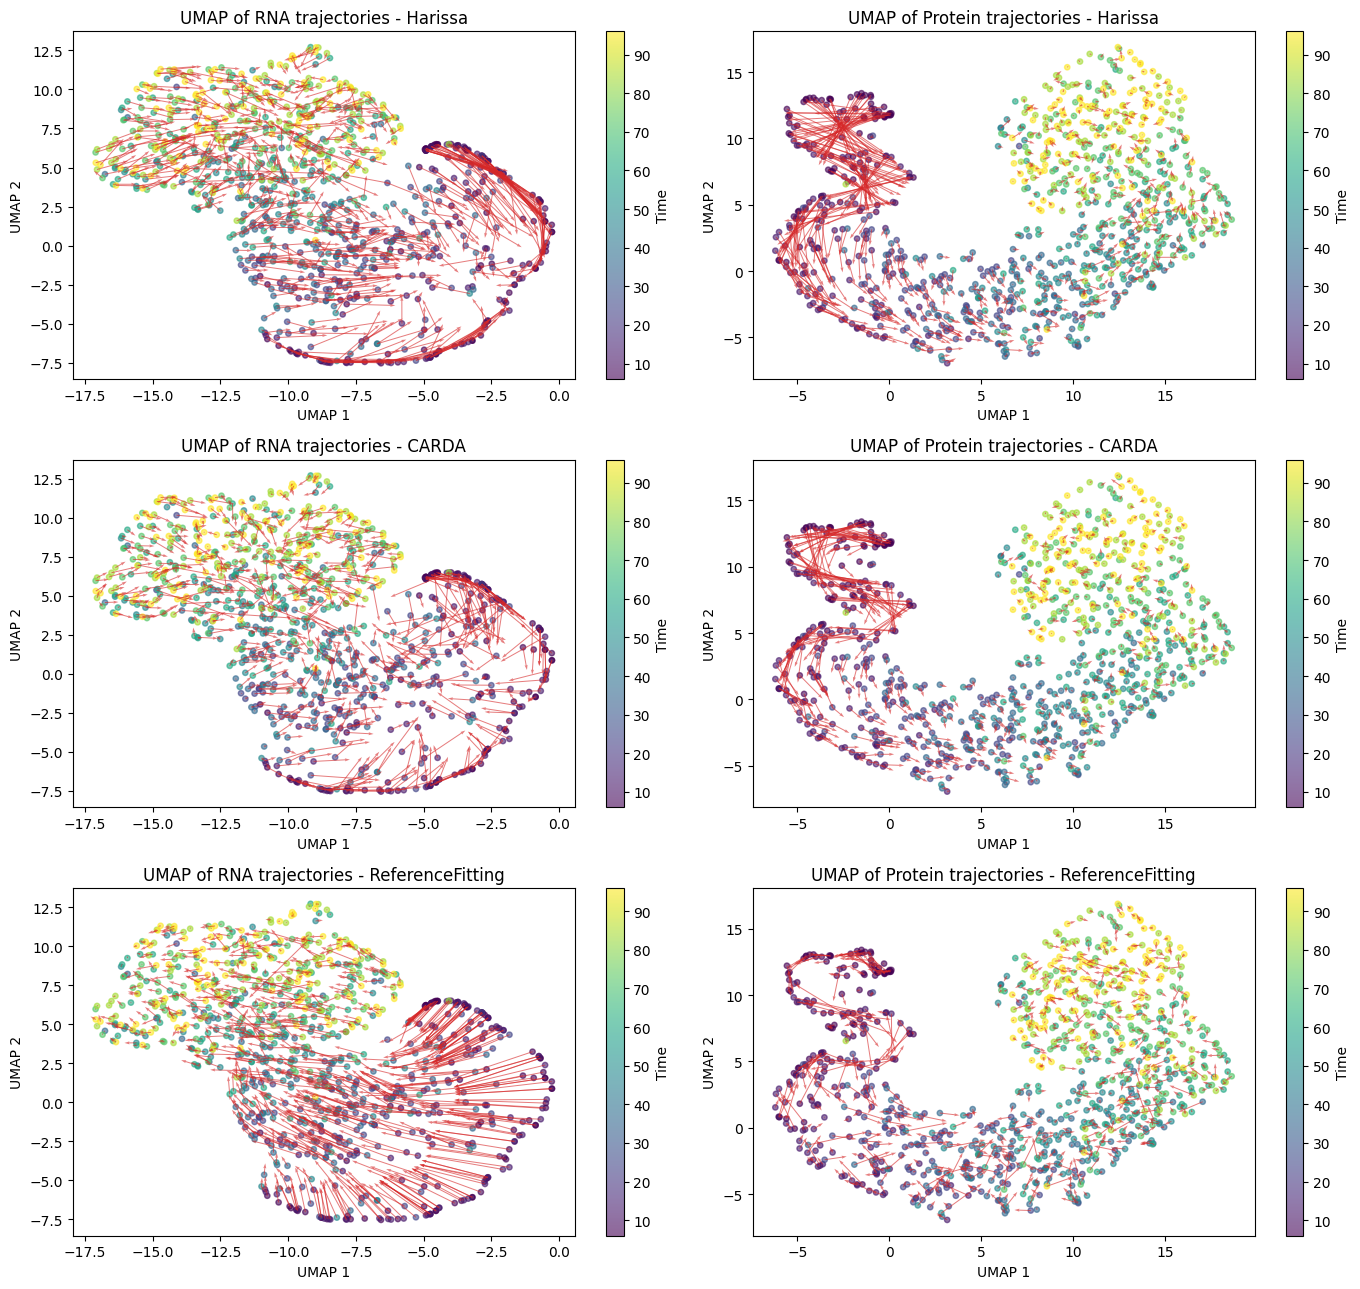

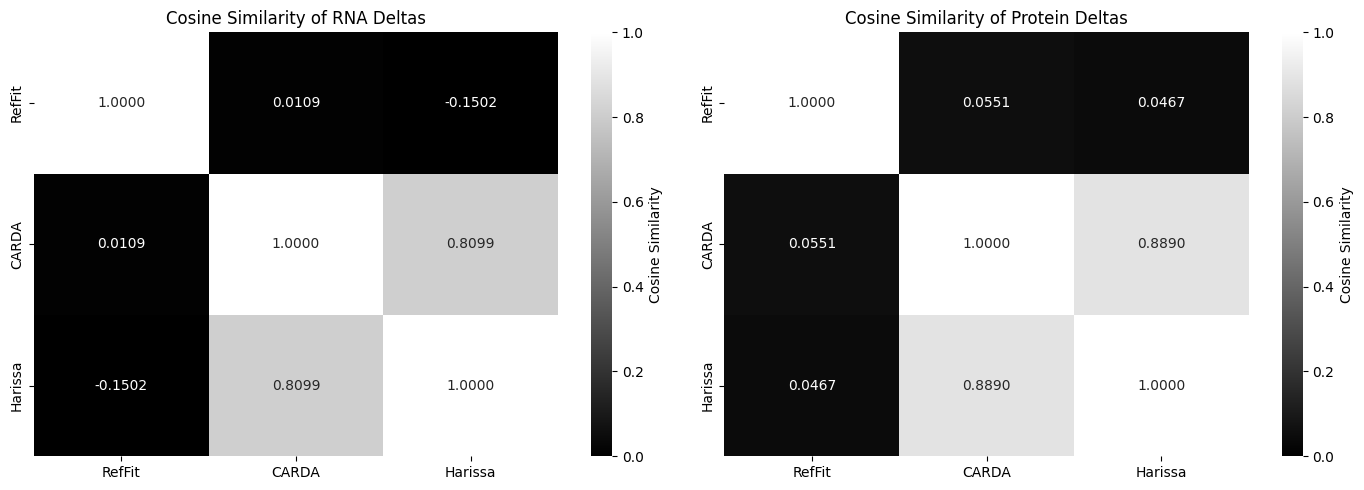

In [7]:
FN8_RNA, FN8_prot, FN8_UMAPs, FN8_cells = run_fig_5('FN8')

# CN5

In [8]:
np.random.seed(0)

# Number of cells
C = 1000
t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96]
N = int(C /len(t))
k = np.linspace(0, C, len(t) + 1, dtype='int')
print(f't = {t}')
time = np.zeros(C, dtype='int')
for i in range(len(t)): time[k[i]:k[i+1]] = t[i]

# Number of genes
G = 5

# Prepare data
data = np.zeros((C+1,G+2), dtype='int')
data[0][1:] = np.arange(G+1)
data[1:,0] = time # Time points
data[1:,1] = 100 * (time > 0) # Stimulus

# Initialize the model
model_harissa = HarissaNetworkModel(G)
model_harissa.d[0] = 0.5
model_harissa.d[1] = 0.1

model_harissa.basal[1:] = [-5, 4, 4, -5, -5]
model_harissa.inter[0, 1] = 10
model_harissa.inter[1, 2] = -10
model_harissa.inter[2, 3] = -10
model_harissa.inter[3, 4] = 10
model_harissa.inter[4, 5] = 10
model_harissa.inter[5, 1] = -10

inter_true = 1 * (abs(model_harissa.inter) > 0)

prot_traj = np.ones((C, G+1), dtype='float32')
for k in range(C):
    sim = model_harissa.simulate(time[k], burnin=5)
    prot_traj[k,1:] = sim.p[-1]
    data[k+1,2:] = np.random.poisson(sim.m[-1])
rna_traj = data[1:,1:].copy()
prot_traj_scaled = prot_traj / np.max(prot_traj, axis=0)

t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96]


(1000, 6)
Calibrating gene 1
Calibrating gene 2
Calibrating gene 3
Calibrating gene 4
Calibrating gene 5
Gene 1-1 calibrated... [0.01  2.009] 0.02013331639281776
Gene 2-2 calibrated... [0.147 2.611] 0.02748129238295783
Gene 3-3 calibrated... [0.318 2.965] 0.029405040774904752
Gene 4-4 calibrated... [0.118 2.188] 0.023575504053674087
Gene 5-5 calibrated... [0.008 1.316] 0.015531448409116225
Mean proba =  0.9314238475217135 1.0
[fit_network] Cell counts per sample/timepoint and genes:
 [[100 100 100 100 100 100 100 100 100 100]] 6
[fit_network] Number of simulated cells per sample: [100]
[fit_network] Number of total cells per sample: [100]
1 0 | Errors (before, after): 0.68649, 0.44649 | alpha mean: 0.0100
number of non reached cells 341
2 0 | Errors (before, after): 0.43298, 0.42712 | alpha mean: 0.0857
number of non reached cells 346
3 0 | Errors (before, after): 0.38479, 0.37817 | alpha mean: 0.1280
number of non reached cells 331
4 0 | Errors (before, after): 0.34770, 0.33788 | alph

2026-03-25 16:22:18,506 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 2.163070e-03 max scale = 1.321e+00
2026-03-25 16:22:18,507 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 3.457893e-03 max scale = 1.321e+00
2026-03-25 16:22:18,514 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 9.359056e-03 max scale = 1.321e+00
2026-03-25 16:22:18,517 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 1.030882e-02 max scale = 1.321e+00
2026-03-25 16:22:18,518 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 1.122679e-02 max scale = 1.306e+00
2026-03-25 16:22:18,519 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 1.176978e-02 max scale = 1.306e+00
2026-03-25 16:22:18,521 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 1.287786e-02 max scale = 1.306e+00
2026-03-25 16:22:18,524 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 9.677344e-03 max scale = 1.306e+00


[adapt_unitary]  Static network unitary [array([[ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [13.121,  3.377, -0.001, -5.235,  0.002, -7.449],
       [ 0.   , -5.56 ,  2.887, -0.   ,  3.186,  0.   ],
       [-2.255, -0.028, -8.236,  3.516, -0.   , -4.057],
       [ 2.484,  4.132, -0.48 , 10.245,  3.546,  0.191],
       [ 1.157,  0.   , -3.129,  3.114,  5.934,  2.564]])] [array([  0.   ,  -5.813,  -0.453,   6.326, -12.421,  -5.045])]
Updating transport plans
iteration 0, loss = -17362.378112293183, L = -17362.378112293183, R = 0.0
iteration 10, loss = -18450.957040817102, L = -18458.54170728233, R = 7.584666465225448
iteration 20, loss = -19032.756221007632, L = -19045.859177263384, R = 13.10295625575179
iteration 30, loss = -19405.265117939187, L = -19422.25884732445, R = 16.99372938526467
iteration 40, loss = -19634.507923164434, L = -19654.969759439617, R = 20.46183627518315
iteration 50, loss = -19774.138846473157, L = -19798.4297584116, R = 24.29091193844333
iteration 6

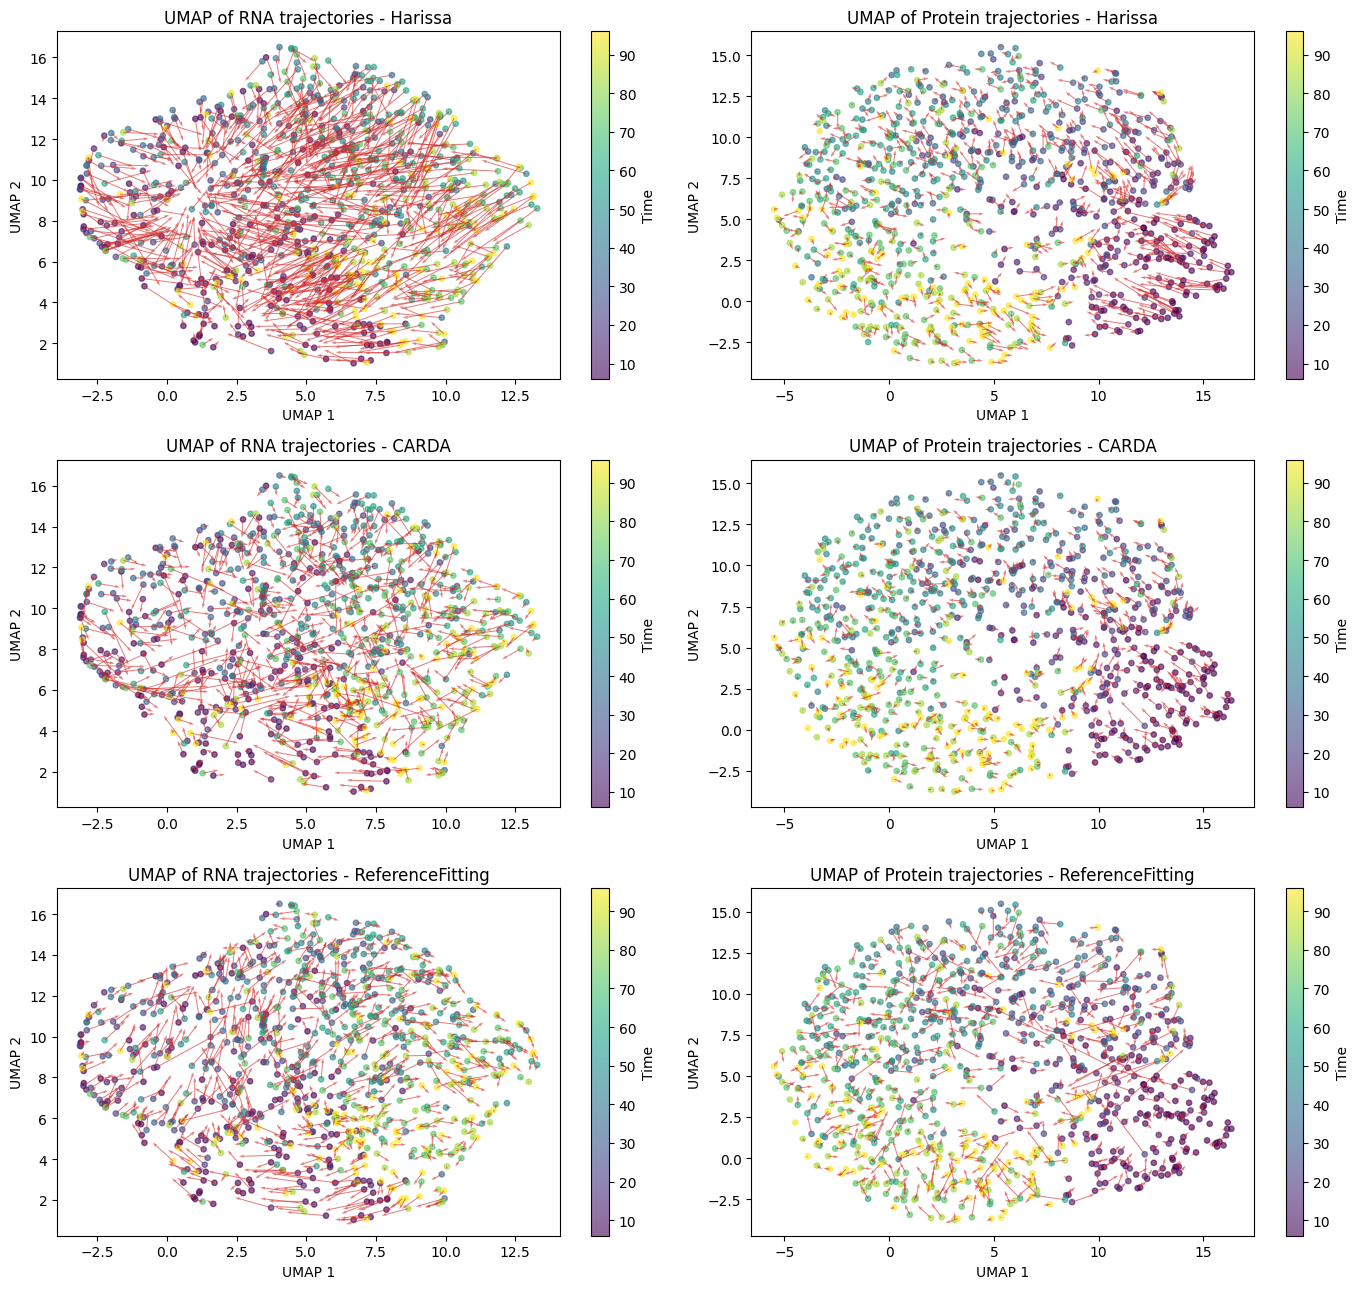

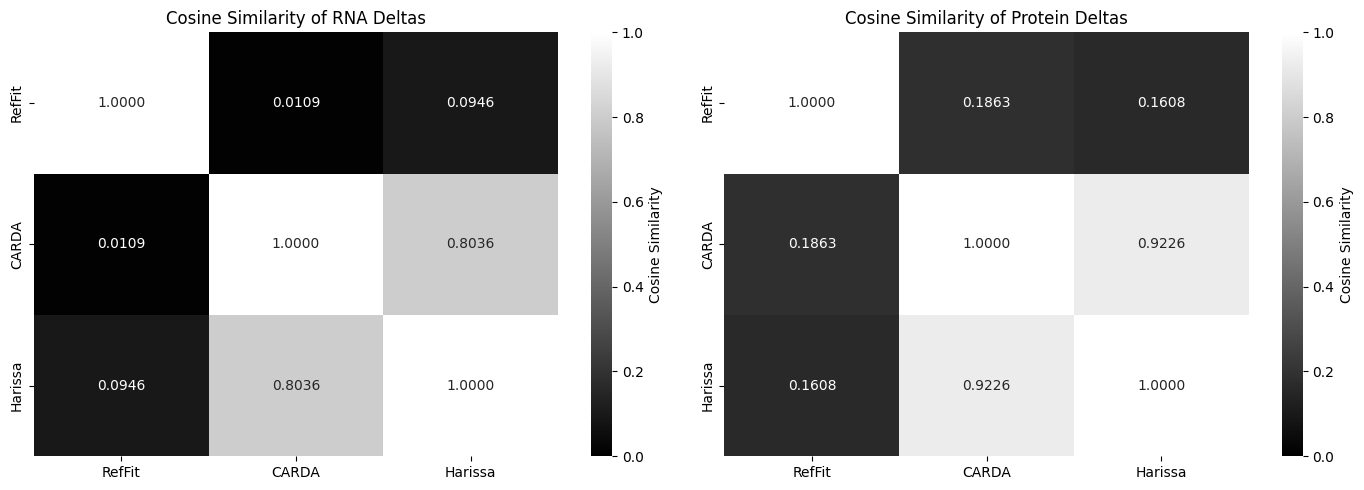

In [9]:
CN5_RNA, CN5_prot, CN5_UMAPs, CN5_cells = run_fig_5('CN5')

# FN4

In [10]:
np.random.seed(0)

# Number of cells
C = 1000
t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96]
N = int(C /len(t))
k = np.linspace(0, C, len(t) + 1, dtype='int')
print(f't = {t}')
time = np.zeros(C, dtype='int')
for i in range(len(t)): time[k[i]:k[i+1]] = t[i]

# Number of genes
G = 5

# Prepare data
data = np.zeros((C+1,G+2), dtype='int')
data[0][1:] = np.arange(G+1)
data[1:,0] = time # Time points
data[1:,1] = 100 * (time > 0) # Stimulus

# Initialize the model
model_harissa = HarissaNetworkModel(G)
model_harissa.d[0] = 1
model_harissa.d[1] = 0.2
model_harissa.d /= 5

model_harissa.basal[1:] = -5
model_harissa.inter[0,1] = 10
model_harissa.inter[1,2] = 10
model_harissa.inter[1,3] = 10
model_harissa.inter[3,4] = 10
model_harissa.inter[4,1] = -10
model_harissa.inter[2,2] = 10
model_harissa.inter[3,3] = 10

inter_true = 1 * (abs(model_harissa.inter) > 0)

prot_traj = np.ones((C, G+1), dtype='float32')
for k in range(C):
    sim = model_harissa.simulate(time[k], burnin=5)
    prot_traj[k,1:] = sim.p[-1]
    data[k+1,2:] = np.random.poisson(sim.m[-1])
rna_traj = data[1:,1:].copy()
prot_traj_scaled = prot_traj / np.max(prot_traj, axis=0)

t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96]


(1000, 6)
Calibrating gene 1
Calibrating gene 2
Calibrating gene 3
Calibrating gene 4
Calibrating gene 5
Gene 1-1 calibrated... [0.012 2.221] 0.023878647853259598
Gene 2-2 calibrated... [0.011 2.75 ] 0.02287085372071124
Gene 3-3 calibrated... [0.011 2.26 ] 0.02202347927204575
Gene 4-4 calibrated... [0.009 1.599] 0.018107125214276765
Gene 5-5 calibrated... [0.009 0.922] 0.0673418096773202
Mean proba =  0.973942575595498 1.0
[fit_network] Cell counts per sample/timepoint and genes:
 [[100 100 100 100 100 100 100 100 100 100]] 6
[fit_network] Number of simulated cells per sample: [100]
[fit_network] Number of total cells per sample: [100]
1 0 | Errors (before, after): 0.69399, 0.23966 | alpha mean: 0.0100
number of non reached cells 321
2 0 | Errors (before, after): 0.22698, 0.22282 | alpha mean: 0.0248
number of non reached cells 313
3 0 | Errors (before, after): 0.20695, 0.20313 | alpha mean: 0.0378
number of non reached cells 338
4 0 | Errors (before, after): 0.17709, 0.17243 | alpha m

2026-03-25 16:23:05,149 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 2.574718e-03 max scale = 1.321e+00
2026-03-25 16:23:05,157 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 1.002848e-02 max scale = 1.321e+00
2026-03-25 16:23:05,158 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 8.498734e-03 max scale = 1.321e+00
2026-03-25 16:23:05,160 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 9.520013e-03 max scale = 1.306e+00
2026-03-25 16:23:05,161 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 8.112249e-03 max scale = 1.321e+00
2026-03-25 16:23:05,162 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 6.092455e-03 max scale = 1.321e+00
2026-03-25 16:23:05,167 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 5.450816e-03 max scale = 1.321e+00
2026-03-25 16:23:05,170 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 6.289860e-03 max scale = 1.321e+00


[adapt_unitary]  Static network unitary [array([[ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 9.372,  6.3  , -1.215, -0.192, -5.161,  0.   ],
       [ 0.002,  6.689,  7.002, -0.   , -0.243, -0.   ],
       [-0.   ,  8.219, -0.001,  6.026,  0.001, -0.   ],
       [ 0.   ,  0.   , -0.   ,  6.359,  2.881,  0.   ],
       [ 0.   ,  0.   ,  0.041,  0.   ,  0.001,  0.642]])] [array([ 0.   , -7.905, -5.714, -6.205, -4.427, -3.35 ])]
Updating transport plans
iteration 0, loss = -13031.778421629346, L = -13031.778421629346, R = 0.0
iteration 10, loss = -13670.407746814699, L = -13675.628004767974, R = 5.220257953274112
iteration 20, loss = -13933.657707695336, L = -13942.277232046521, R = 8.619524351185195
iteration 30, loss = -14065.195136111257, L = -14075.55056532904, R = 10.355429217783183
iteration 40, loss = -14136.391641888122, L = -14148.129901350854, R = 11.73825946273207
iteration 50, loss = -14174.4294570082, L = -14187.363574220724, R = 12.934117212524045
iteration 60, 

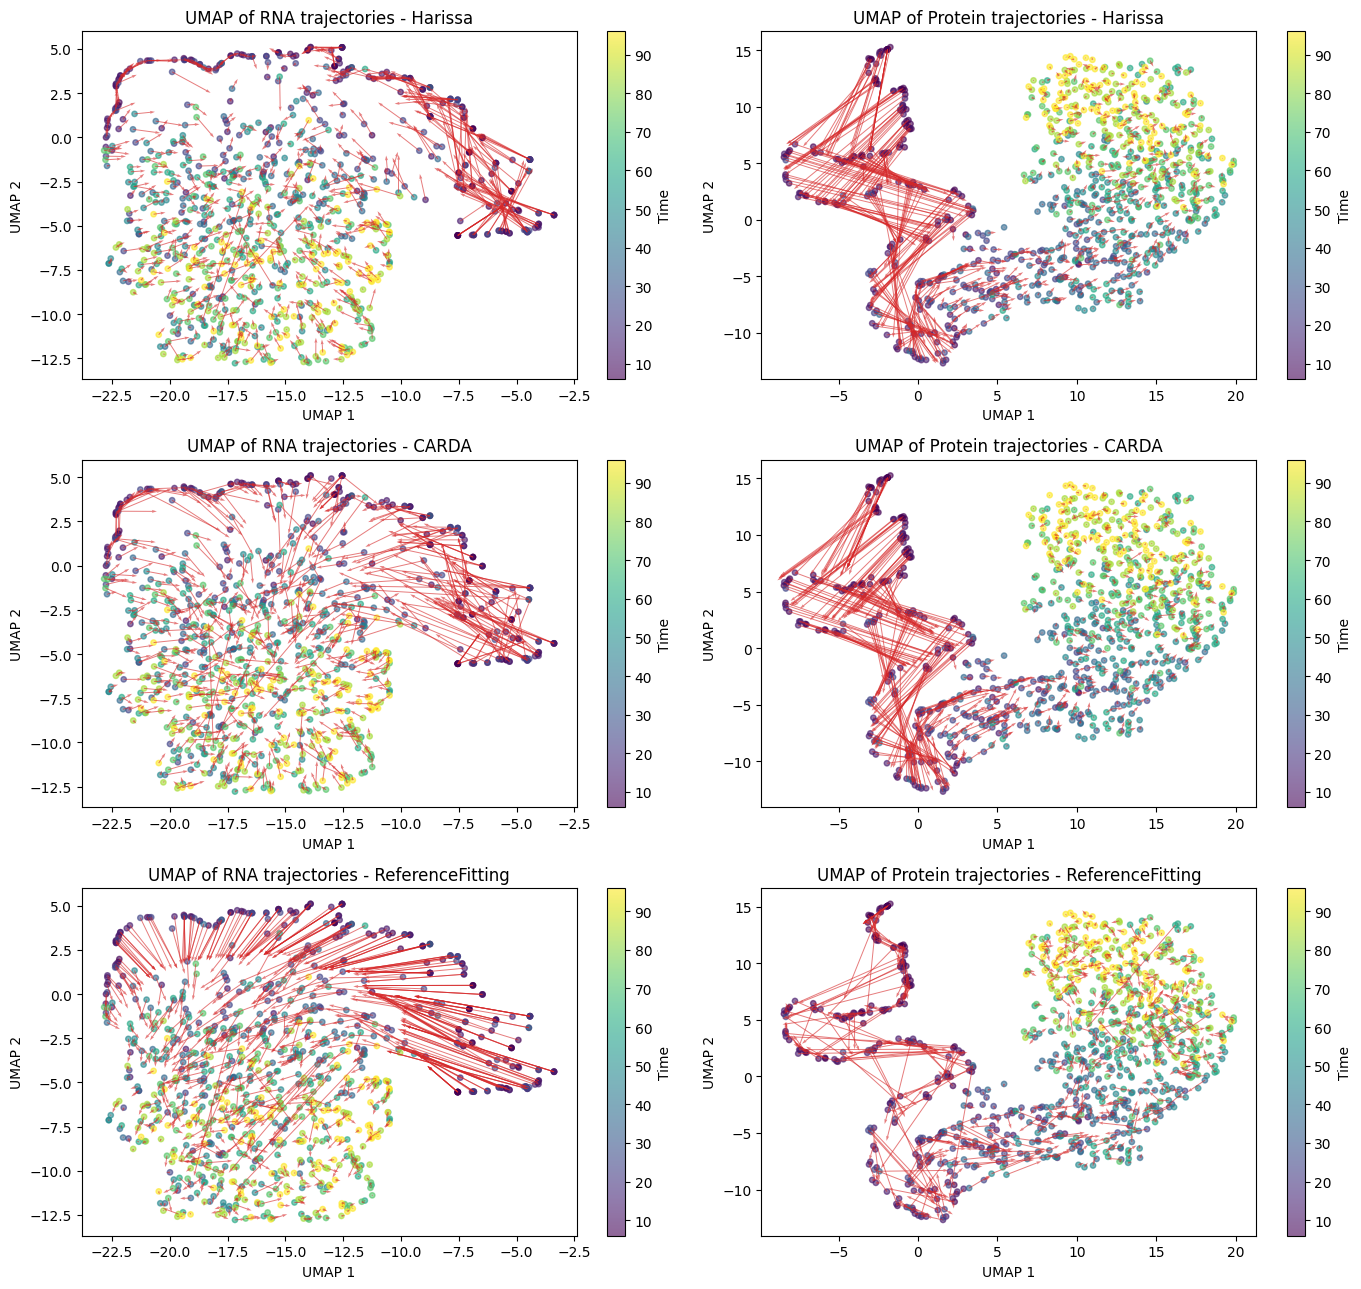

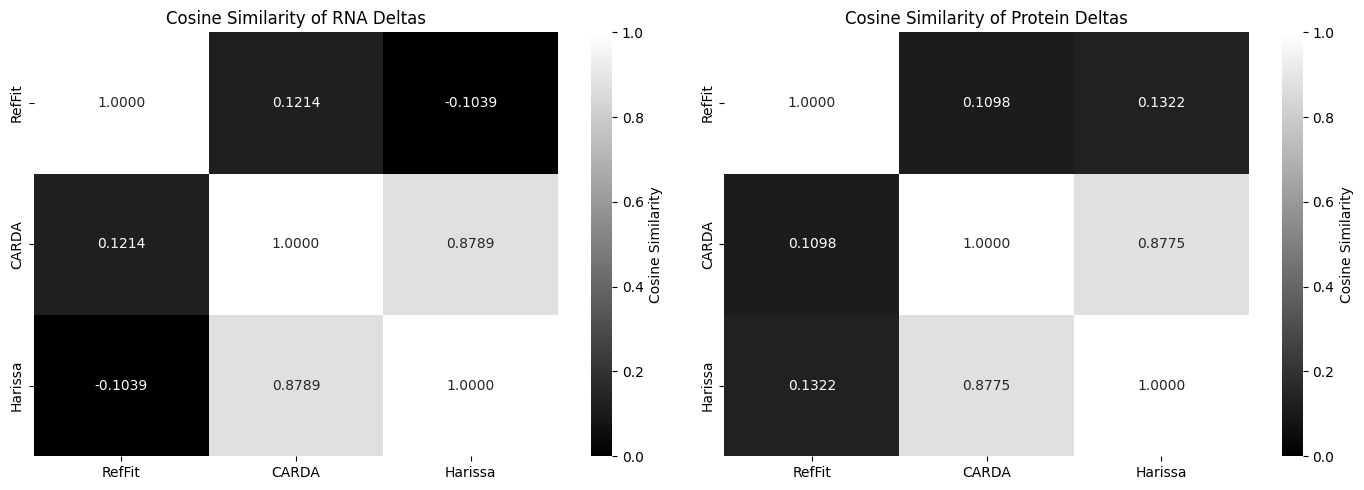

In [11]:
FN4_RNA, FN4_prot, FN4_UMAPs, FN4_cells = run_fig_5('FN4')

# Schiebinger

## Model Fit
Model is fitted from data is this subsection. We load pre-fitted weigths in the following subsection for reduced compute time and figure reproducibility

In [ ]:
adata = sc.read('../../../../data/Datas_exp/Schiebinger/Data/data_train.h5ad')
n_per_time = 50
np.random.seed(0)
time_vals = np.array(adata.obs['time'])
subsample_indices = []
for t in np.unique(time_vals):
    time_indices = np.where(time_vals == t)[0]
    n_sample = min(n_per_time, len(time_indices))
    sampled = np.random.choice(time_indices, size=n_sample, replace=False)
    subsample_indices.extend(sampled)
adata = adata[np.array(subsample_indices)].copy()

In [ ]:
time_schiebinger = np.array(adata.obs['time'])
rna_traj = adata.X.toarray().copy()
x = adata.X.toarray().copy()
x = np.insert(x, 0, time_schiebinger, axis=1)
G = np.size(x, 1)
model = CardamomNetworkModel(G - 1)
print(x.shape)
model.fit_mixture(x, gene_names=list(adata.var_names), 
                    min_components=2, max_components=2, max_iter_kinetics=0)
model.fit_network(x, intensity_prior=100)
model.adapt_to_unitary()

# Calculation of delta on Carda
c = model.a[-1]
ks_cells = np.max(model.a[:-1], axis=0)
ks = (model.a[:-1] / np.max(model.a[:-1], axis=0)).T
d0 = model.d[0]
d1 = model.d[1]

(1850, 109)


2026-02-10 11:15:50.710780: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-10 11:15:50.710786: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-10 11:15:50.710783: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-10 11:15:50.710783: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-10 11:15:50.710786: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-10 11:15:50.710789: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-10 11:15:50.710784: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-10 11:15:50.710780: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-

Calibrating gene 7
Calibrating gene 11
Calibrating gene 19
Calibrating gene 1
Calibrating gene 18
Calibrating gene 15
Calibrating gene 14
Calibrating gene 8
Calibrating gene 5
Calibrating gene 10
Calibrating gene 12
Calibrating gene 6
Calibrating gene 3
Calibrating gene 4
Calibrating gene 13
Calibrating gene 16
Calibrating gene 9
Calibrating gene 17
Calibrating gene 2
Calibrating gene 20
Calibrating gene 21
Calibrating gene 22
Calibrating gene 23
Calibrating gene 24
Calibrating gene 25
Calibrating gene 26
Calibrating gene 27
Calibrating gene 28
Calibrating gene 29
Calibrating gene 30
Calibrating gene 31
Calibrating gene 32
Calibrating gene 33
Calibrating gene 34
Calibrating gene 35
Calibrating gene 36
Calibrating gene 37
Calibrating gene 38
Calibrating gene 39
Calibrating gene 40
Calibrating gene 41
Calibrating gene 42
Calibrating gene 43
Calibrating gene 44
Calibrating gene 45
Calibrating gene 46
Calibrating gene 47
Calibrating gene 48
Calibrating gene 49
Calibrating gene 50
Calibrati

/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


3 0 | Errors (before, after): 0.38139, 0.37507 | alpha mean: 0.1724
number of non reached cells 648


...

Minimization failed for refining
8 0 | Errors (before, after): 0.35076, 0.34644 | alpha mean: 0.2776
number of non reached cells 577


/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


9 0 | Errors (before, after): 0.34515, 0.34108 | alpha mean: 0.2935
number of non reached cells 539


/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Minimization failed for refining
10 0 | Errors (before, after): 0.34117, 0.33763 | alpha mean: 0.2953
number of non reached cells 503
Minimization failed for refining
11 0 | Errors (before, after): 0.34424, 0.34048 | alpha mean: 0.2955
number of non reached cells 497
12 1 | Errors (before, after): 0.34069, 0.33752 | alpha mean: 0.3051
number of non reached cells 471
13 1 | Errors (before, after): 0.33836, 0.33538 | alpha mean: 0.3073
number of non reached cells 463
Minimization failed for refining
14 1 | Errors (before, after): 0.33762, 0.33416 | alpha mean: 0.3057
number of non reached cells 453
15 1 | Errors (before, after): 0.33584, 0.33278 | alpha mean: 0.3106
number of non reached cells 444
Minimization failed for refining
16 1 | Errors (before, after): 0.33548, 0.33251 | alpha mean: 0.3108
number of non reached cells 423
17 1 | Errors (before, after): 0.33497, 0.33239 | alpha mean: 0.3196
number of non reached cells 424
18 1 | Errors (before, after): 0.33339, 0.33061 | alpha mean

## Loading weights

In [12]:
rna_traj = np.load('../../../../data/Datas_exp/Schiebinger/cardamom/data_rna.npy')[:,1:]
G = rna_traj.shape[1]
model = CardamomNetworkModel(G)
model.d = np.load('../../../../data/Datas_exp/Schiebinger/cardamom/degradations.npy')
model.basal = np.load('../../../../data/Datas_exp/Schiebinger/cardamom/basal_simul.npy')
model.inter = np.load('../../../../data/Datas_exp/Schiebinger/cardamom/inter_simul.npy')
model.prot = np.load('../../../../data/Datas_exp/Schiebinger/cardamom/data_prot.npy')
model.kon_theta = np.load('../../../../data/Datas_exp/Schiebinger/cardamom/data_kon_theta.npy')
model.a = np.load('../../../../data/Datas_exp/Schiebinger/cardamom/mixture_parameters.npy')
time_schiebinger = np.load('../../../../data/Datas_exp/Schiebinger/cardamom/data_times.npy')

# Subsample 25 cells per time point to plot
n_per_time = 200
np.random.seed(0)
subsample_indices = []
for t in np.unique(time_schiebinger):
    time_indices = np.where(time_schiebinger == t)[0]
    n_sample = min(n_per_time, len(time_indices))
    sampled = np.random.choice(time_indices, size=n_sample, replace=False)
    subsample_indices.extend(sampled)
subsample_indices = np.array(subsample_indices)

time_schiebinger = time_schiebinger[subsample_indices]
rna_traj = rna_traj[subsample_indices]
model.prot = model.prot[subsample_indices]
model.kon_theta = model.kon_theta[subsample_indices]

c = model.a[-1]
ks_cells = np.max(model.a[:-1], axis=0)
ks = (model.a[:-1] / np.max(model.a[:-1], axis=0)).T
d0 = model.d[0]
d1 = model.d[1]

## Delta/UMAP calculation

In [13]:
infered_prot_traj = model.prot[:, 1:]
delta_rna_carda = d0[1:] * (model.kon_theta[:, 1:] * ks_cells[1:] / c[1:] - rna_traj)
delta_prot_carda = np.zeros_like(infered_prot_traj, dtype=float)
for cell in range(infered_prot_traj.shape[0]):
   Pnew, delta_P = step_ode_modif(d1[1:]*50, ks[1:], model.inter[1:, 1:], model.basal[1:], 1
                               , infered_prot_traj[cell].reshape(1, -1))
   delta_prot_carda[cell] = delta_P[0]

k = 8
if False:
   n_rows, n_cols = delta_prot_carda.shape
   k = min(k, n_cols)
   topk_idx = np.argpartition(np.abs(delta_prot_carda), -k, axis=1)[:, -k:]
   mask = np.zeros_like(delta_prot_carda, dtype=bool)
   rows = np.arange(n_rows)[:, None]
   mask[rows, topk_idx] = True
   delta_prot_carda[:] = np.where(mask, delta_prot_carda, 0.0)
if True:
   n_rows, n_cols = delta_rna_carda.shape
   k = min(k, n_cols)
   topk_idx = np.argpartition(np.abs(delta_rna_carda), -k, axis=1)[:, -k:]
   mask = np.zeros_like(delta_rna_carda, dtype=bool)
   rows = np.arange(n_rows)[:, None]
   mask[rows, topk_idx] = True
   delta_rna_carda[:] = np.where(mask, delta_rna_carda, 0.0)

umap_x = UMAP(n_components=2, random_state=42, min_dist=0.7)
umap_prot = UMAP(n_components=2, random_state=42, min_dist=0.7)
rna_endpoints = rna_traj + delta_rna_carda
prot_endpoints = infered_prot_traj + delta_prot_carda
rna_endpoints = np.maximum(rna_endpoints, 0)
prot_endpoints = np.maximum(prot_endpoints, 0)
rna_traj_adata = ad.AnnData(X=rna_traj.copy())
rna_endpoints_adata = ad.AnnData(X=rna_endpoints.copy())
sc.pp.normalize_total(rna_traj_adata, target_sum=1e4)
sc.pp.normalize_total(rna_endpoints_adata, target_sum=1e4)
sc.pp.log1p(rna_traj_adata)
sc.pp.log1p(rna_endpoints_adata)
rna_traj = rna_traj_adata.X.copy()
rna_endpoints = rna_endpoints_adata.X.copy()

umap_x.fit(rna_traj)
umap_prot.fit(infered_prot_traj)
rna_traj_2d = umap_x.transform(rna_traj)
prot_traj_2d = umap_prot.transform(infered_prot_traj)
delta_rna_carda_2d = (umap_x.transform(rna_endpoints) - rna_traj_2d)
delta_prot_carda_2d = (umap_prot.transform(prot_endpoints) - prot_traj_2d)

# Fig

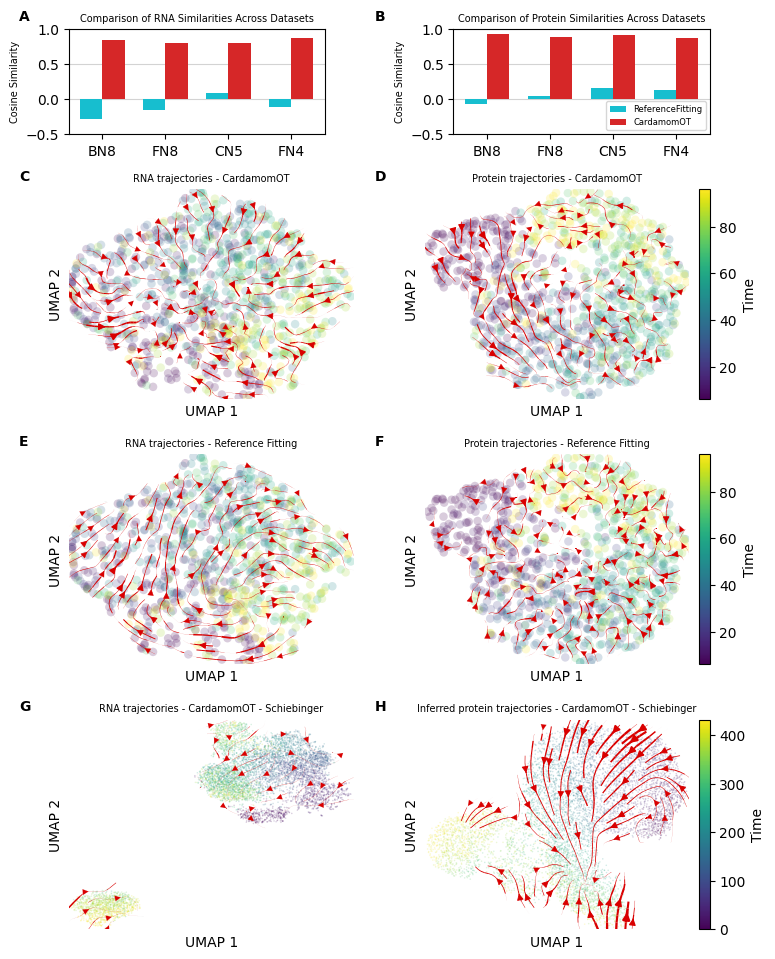

In [37]:

import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable

# --- Figure layout ---
fig = plt.figure(figsize=(8.27, 11.69))
gs = gridspec.GridSpec(4, 1, figure=fig, height_ratios=[1, 2, 2, 2], hspace=0.3)
wspaces = [0.5, 0.25, 0.25, 0.25]
subplot_specs = [gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[i], wspace=w)
                 for i, w in enumerate(wspaces)]
axes = [fig.add_subplot(spec[0, c]) for spec in subplot_specs for c in range(2)]

# --- Panel labels ---
x_left  = min(axes[i].get_position().x0 for i in range(0, 8, 2))
x_right = min(axes[i].get_position().x0 for i in range(1, 8, 2))
x_offset = 0.06
for i, (ax, label) in enumerate(zip(axes, "ABCDEFGH")):
    x_fig = (x_left if i % 2 == 0 else x_right) - x_offset
    fig.text(x_fig, ax.get_position().y1 + 0.005, label,
             ha="left", va="bottom", fontsize=10, fontweight="bold", clip_on=False)

# --- Bar charts (RNA left, Protein right) ---
dataset_titles = ['BN8', 'FN8', 'CN5', 'FN4']
bar_methods    = ['ReferenceFitting', 'CardamomOT']
bar_colors     = [colors_methods['REFERENCE_FITTING'][0], colors_methods['CardamomOT'][0]]
x = np.arange(len(dataset_titles))
width = 0.35

bar_configs = [
    (axes[0], [BN8_RNA,  FN8_RNA,  CN5_RNA,  FN4_RNA],  'Comparison of RNA Similarities Across Datasets',     (-0.5, 1), False),
    (axes[1], [BN8_prot, FN8_prot, CN5_prot, FN4_prot], 'Comparison of Protein Similarities Across Datasets', (-0.5, 1), True),
]
for ax, matrices, title, ylim, show_legend in bar_configs:
    for idx, (method, color) in enumerate(zip(bar_methods, bar_colors)):
        ax.bar(x + idx * width, [m[2, idx] for m in matrices], width, label=method, color=color)
    ax.set_ylabel('Cosine Similarity', fontsize=7)
    ax.set_title(title, fontsize=7)
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(dataset_titles)
    ax.set_ylim(*ylim)
    ax.yaxis.grid(True, color='lightgray', linewidth=0.8)
    ax.set_axisbelow(True)
    if show_legend:
        ax.legend(loc='lower right', fontsize=6)

# --- Velocity stream helper ---
DENSITY, SMOOTH = 1, 0.5

def make_adata_plot(embedding, velocity, time_vals):
    ap = ad.AnnData(X=embedding.astype(np.float32))
    ap.obs['time'] = time_vals.astype(float)
    ap.obsm['X_umap'] = embedding
    ap.obsm['velocity_umap'] = velocity
    return ap

def plot_stream(ax, embedding, velocity, time_vals, title, size=15, add_colorbar=False):
    scv.pl.velocity_embedding_stream(
        make_adata_plot(embedding, velocity, time_vals),
        basis='umap', ax=ax, color='time', cmap='viridis', arrow_color=(0.85, 0.0, 0.0, 1.0),
        alpha=0.2, size=size, show=False, colorbar=False, density=DENSITY, smooth=SMOOTH)
    ax.set(xlabel='UMAP 1', ylabel='UMAP 2', title=title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.title.set_fontsize(7)
    if add_colorbar:
        sm = ScalarMappable(cmap='viridis', norm=Normalize(vmin=time_vals.min(), vmax=time_vals.max()))
        sm.set_array([])
        cax = make_axes_locatable(ax).append_axes("right", size="4%", pad=0.1)
        plt.colorbar(sm, cax=cax, label='Time')

# --- CN5 protein UMAP ----
fn4_time = time[100:].astype(float)
prot_CN5 = CN5_cells['prot']
prot_traj_2d_CN5, (delta_prot_carda_2d_CN5, delta_prot_reffit_2d_CN5) = fit_transform_umap(
    prot_CN5,
    prot_CN5 + CN5_cells['prot_carda'],
    prot_CN5 + CN5_cells['prot_reffit'] * 0.1,
    n_components=2, random_state=42, min_dist=0.7)

# --- Stream plots ---
stream_configs = [
    (axes[2], CN5_UMAPs['rna'],  CN5_UMAPs['rna_carda'],    fn4_time,         'RNA trajectories - CardamomOT',                            150, False),
    (axes[3], prot_traj_2d_CN5,  delta_prot_carda_2d_CN5,   fn4_time,         'Protein trajectories - CardamomOT',                        150, True),
    (axes[4], CN5_UMAPs['rna'],  CN5_UMAPs['rna_reffit'],   fn4_time,         'RNA trajectories - Reference Fitting',                     150, False),
    (axes[5], prot_traj_2d_CN5,  delta_prot_reffit_2d_CN5,  fn4_time,         'Protein trajectories - Reference Fitting',                 150, True),
    (axes[6], rna_traj_2d,       delta_rna_carda_2d,        time_schiebinger, 'RNA trajectories - CardamomOT - Schiebinger',               5, False),
    (axes[7], prot_traj_2d,      delta_prot_carda_2d,       time_schiebinger, 'Inferred protein trajectories - CardamomOT - Schiebinger',  5, True),
]
for ax, emb, vel, t, title, size, cbar in stream_configs:
    plot_stream(ax, emb, vel, t, title, size=size, add_colorbar=cbar)

plt.subplots_adjust(hspace=0.2, wspace=0.25)
plt.savefig('figure_5_comparison_combined.png', dpi=600, bbox_inches='tight', pad_inches=0.05)
plt.show()


In [19]:
import importlib, subprocess, sys
if importlib.util.find_spec("PIL") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "Pillow"])
from PIL import Image

img_path = "figure_5_comparison_combined.png"
pdf_path = "figure_5_comparison_combined.pdf"

im = Image.open(img_path)
im.convert('RGB').save(pdf_path, "PDF", resolution=600)
print('Saved', pdf_path)

Saved figure_5_comparison_combined.pdf
